In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure


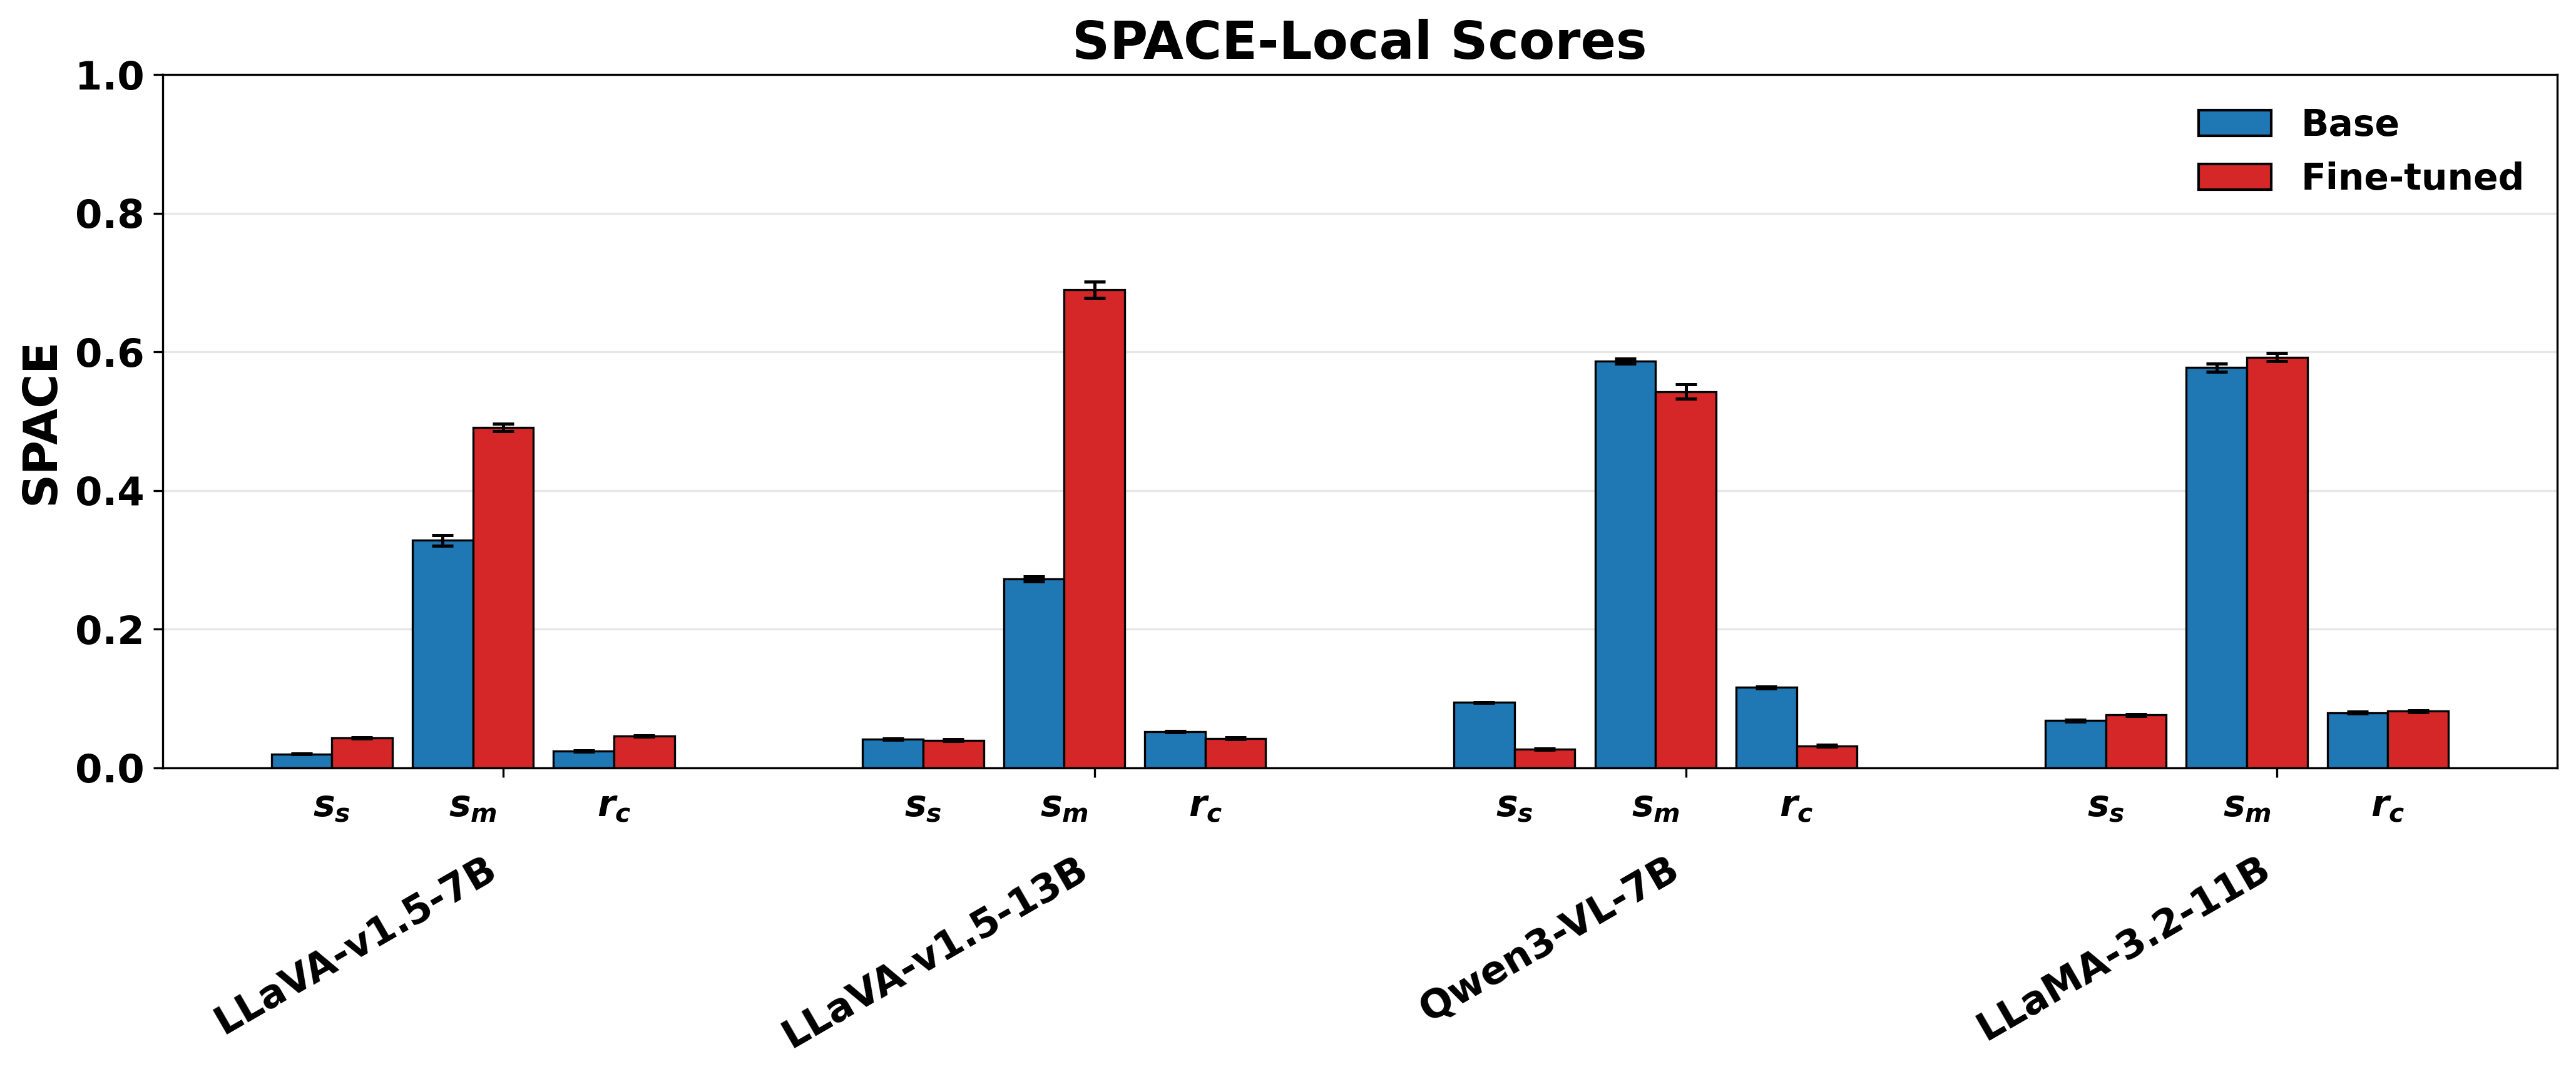

In [2]:
plt.rcParams.update({
    "font.size": 16,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
})

n_groups = 4
bars_per_group = 6        
pairs_per_group = bars_per_group // 2

data = np.array([
    [.0197, .0413, .0941, .0679],
    [.0428, .0396, .0267, .0762],
    [.3280, .2721, .5864, .5771],
    [.4904, .6897, .5426, .5922],
    [.0238, .0521, .1159, .0794],
    [.0457, .0423, .0317, .0815],
])
errors = np.array([
    [0.0005, 0.0008, 0.0008, 0.0013],
    [0.0007, 0.0015, 0.0009, 0.0012],
    [0.0074, 0.0037, 0.0036, 0.0058],
    [0.0054, 0.0118, 0.0101, 0.0059],
    [0.0008, 0.0009, 0.0012, 0.0014],
    [0.001, 0.0015, 0.0010, 0.0013],
])

group_labels = ['LLaVA-v1.5-7B', 'LLaVA-v1.5-13B', 'Qwen3-VL-7B', 'LLaMA-3.2-11B']
pair_labels = [r'$s_s$', r'$s_m$', r'$r_c$']  # example subscripts


bar_width = 0.18
small_gap = 0.06
group_gap = 0.5


x_positions = []
pair_centers = []
group_centers = []

x_cursor = 0.0

for g in range(n_groups):
    group_start = x_cursor
    for p in range(pairs_per_group):
        x_positions.append(x_cursor)
        x_positions.append(x_cursor + bar_width)
        pair_centers.append(x_cursor + bar_width / 2)
        x_cursor += 2 * bar_width + small_gap

    group_end = x_cursor - small_gap
    group_centers.append((group_start + group_end) / 2)

    x_cursor += group_gap

x_positions = np.array(x_positions)


fig, ax = plt.subplots(figsize=(14, 6), dpi=300)

colors = ['tab:blue', 'tab:red']  # alternating colors

bar_idx = 0
for g in range(n_groups):
    for b in range(bars_per_group):
        ax.bar(
            x_positions[bar_idx],
            data[b, g],
            width=bar_width,
            yerr=errors[b, g],
            capsize=4,
            color=colors[b % 2],
            edgecolor='black',
            linewidth=0.8,
            error_kw=dict(
                elinewidth=1.2,
                capthick=1.2
            )
        )
        bar_idx += 1

pair_idx = 0
y_pair = -0.04 * ax.get_ylim()[1]


for g in range(n_groups):
    for p in range(pairs_per_group):
        ax.text(
            pair_centers[pair_idx],
            y_pair,
            pair_labels[p],
            ha='center',
            va='top',
            fontsize=14,
            fontweight='bold'
        )
        pair_idx += 1

ax.set_xticks(group_centers)
ax.set_xticklabels(
    group_labels,
    rotation=30,
    ha='right',
    fontweight='bold'
)

from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=colors[0], edgecolor='black', label='Base'),
    Patch(facecolor=colors[1], edgecolor='black', label='Fine-tuned'),
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc='upper right'
)

ax.tick_params(axis='x', pad=28)

ax.set_ylabel('SPACE')
ax.set_title('SPACE-Local Scores')

ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.ylim([0,1])

plt.tight_layout()
plt.show()



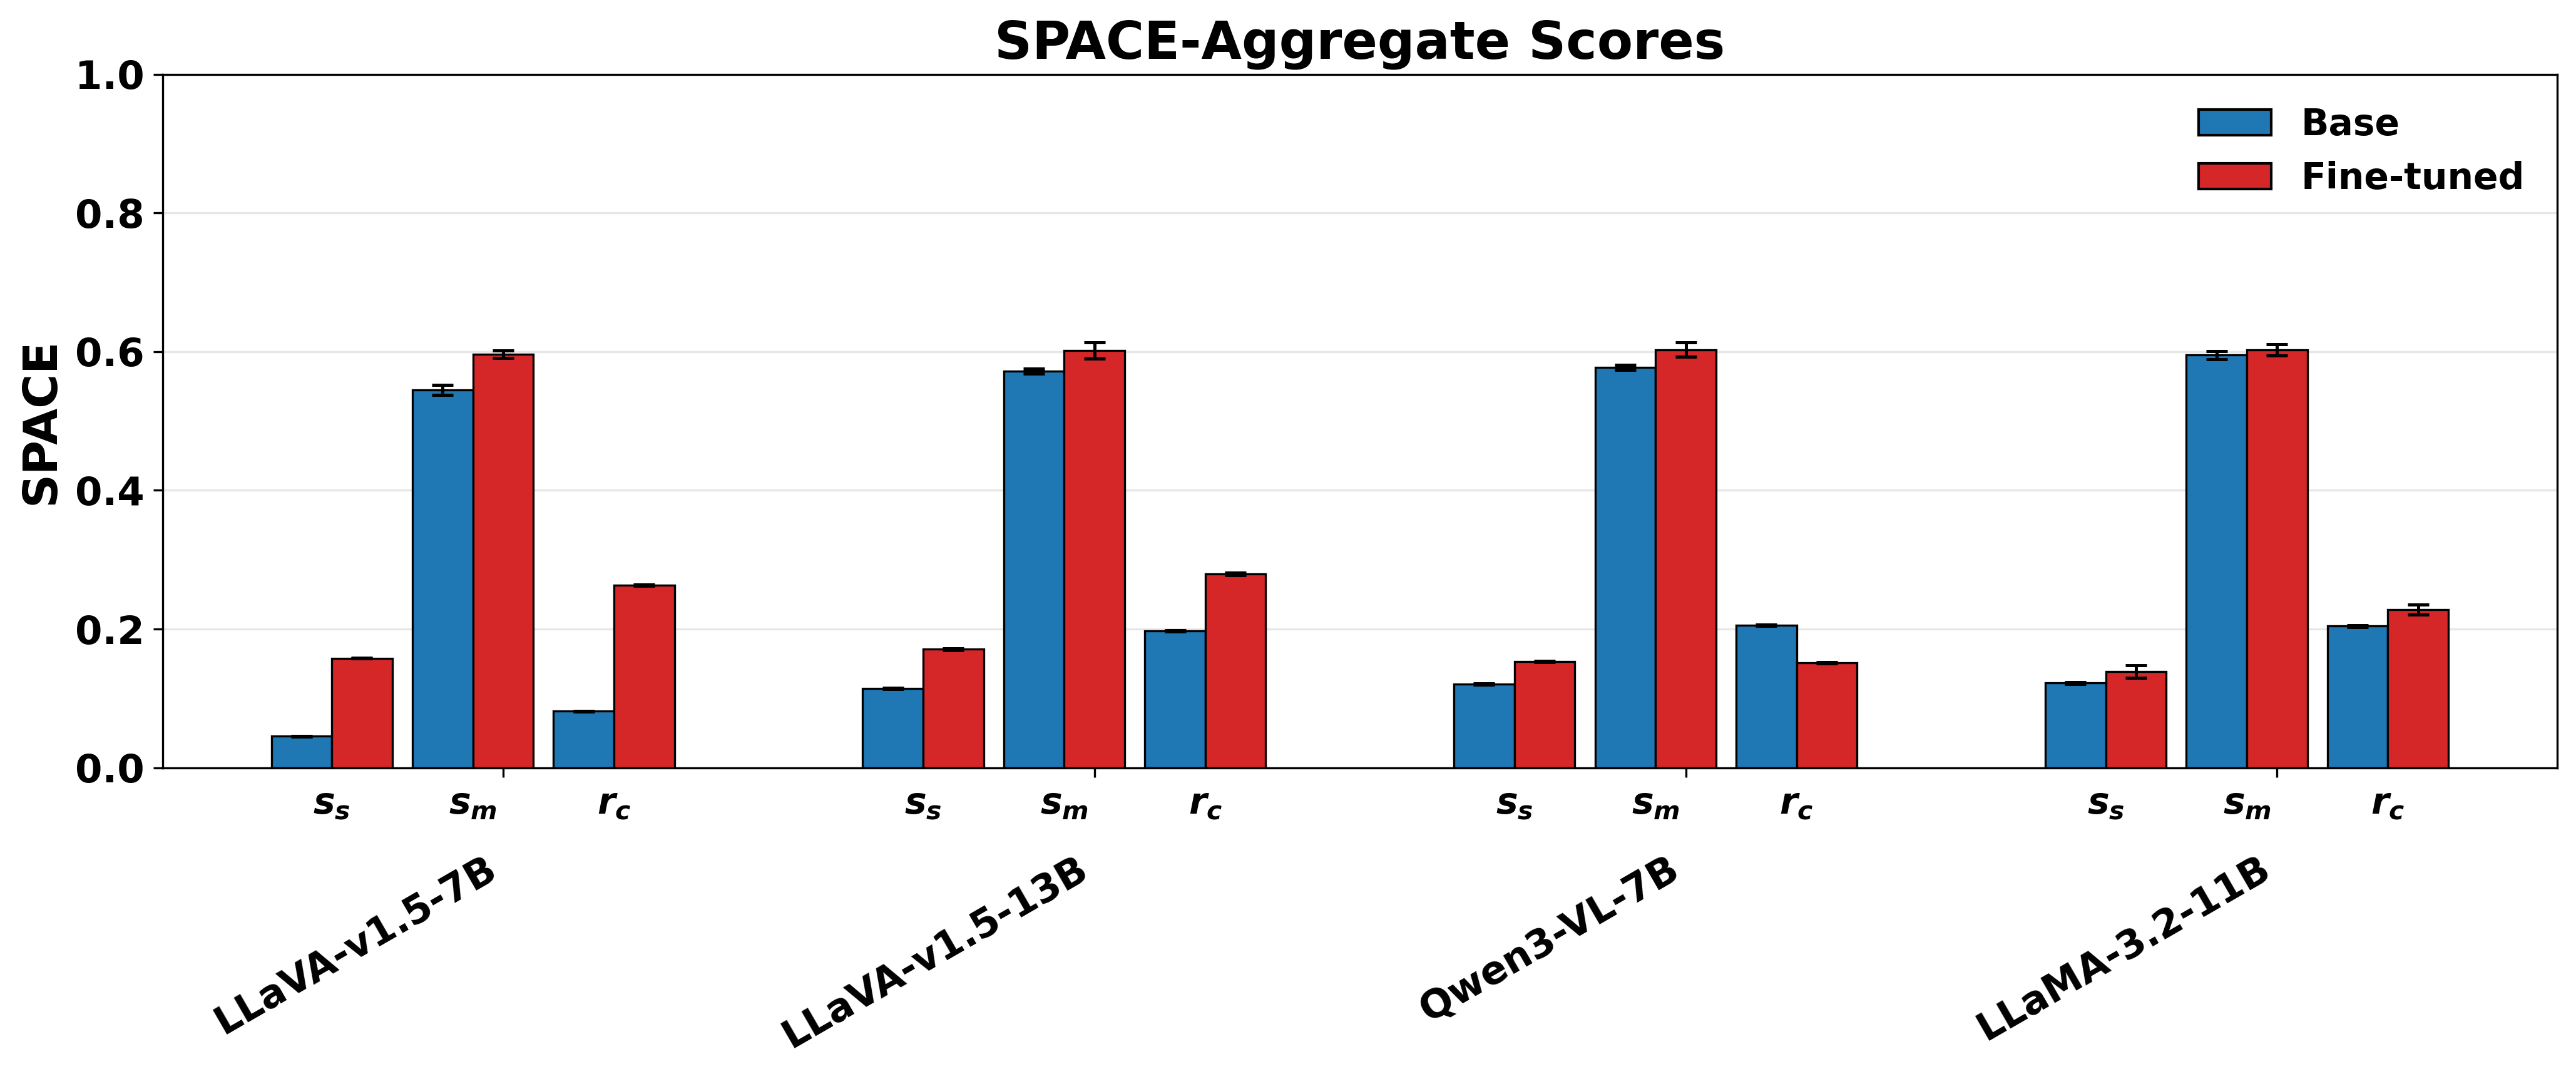

In [3]:

plt.rcParams.update({
    "font.size": 16,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
})


n_groups = 4
bars_per_group = 6        
pairs_per_group = bars_per_group // 2

data = np.array([
    [.0456, .1141, .1208, .1221],
    [.1579, .1710, .1533, .1389],
    [.5450, .5718, .5768, .5950],
    [.5960, .6015, .6028, .6025],
    [.0814, .1970, .2055, .2042],
    [.2632, .2794, .1515, .2277],
])
errors = np.array([
    [0.0005, 0.0008, 0.0008, 0.0013],
    [0.0007, 0.0015, 0.0009, 0.0089],
    [0.0074, 0.0037, 0.0036, 0.0058],
    [0.0054, 0.0118, 0.0101, 0.0079],
    [0.0008, 0.0009, 0.0012, 0.0014],
    [0.001, 0.0015, 0.0010, 0.0073],
])

group_labels = ['LLaVA-v1.5-7B', 'LLaVA-v1.5-13B', 'Qwen3-VL-7B', 'LLaMA-3.2-11B']
pair_labels = [r'$s_s$', r'$s_m$', r'$r_c$']  # example subscripts


bar_width = 0.18
small_gap = 0.06
group_gap = 0.5


x_positions = []
pair_centers = []
group_centers = []

x_cursor = 0.0

for g in range(n_groups):
    group_start = x_cursor
    for p in range(pairs_per_group):
        x_positions.append(x_cursor)
        x_positions.append(x_cursor + bar_width)

        pair_centers.append(x_cursor + bar_width / 2)

        x_cursor += 2 * bar_width + small_gap

    group_end = x_cursor - small_gap
    group_centers.append((group_start + group_end) / 2)

    x_cursor += group_gap

x_positions = np.array(x_positions)


fig, ax = plt.subplots(figsize=(14, 6), dpi=300)

colors = ['tab:blue', 'tab:red']  

bar_idx = 0
for g in range(n_groups):
    for b in range(bars_per_group):
        ax.bar(
            x_positions[bar_idx],
            data[b, g],
            width=bar_width,
            yerr=errors[b, g],
            capsize=4,
            color=colors[b % 2],
            edgecolor='black',
            linewidth=0.8,
            error_kw=dict(
                elinewidth=1.2,
                capthick=1.2
            )
        )
        bar_idx += 1

pair_idx = 0
y_pair = -0.04 * ax.get_ylim()[1]


for g in range(n_groups):
    for p in range(pairs_per_group):
        ax.text(
            pair_centers[pair_idx],
            y_pair,
            pair_labels[p],
            ha='center',
            va='top',
            fontsize=14,
            fontweight='bold'
        )
        pair_idx += 1


ax.set_xticks(group_centers)
ax.set_xticklabels(
    group_labels,
    rotation=30,
    ha='right',
    fontweight='bold'
)

from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=colors[0], edgecolor='black', label='Base'),
    Patch(facecolor=colors[1], edgecolor='black', label='Fine-tuned'),
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc='upper right'
)

ax.tick_params(axis='x', pad=28)

ax.set_ylabel('SPACE')
ax.set_title('SPACE-Aggregate Scores')

ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.ylim([0,1])

plt.tight_layout()
plt.show()